Chapter 6: Finetuning for Text Classification

In [ ]:
# 检查本章所需的第三方库版本,确保运行环境与教程一致
from importlib.metadata import version

# pkgs 列表列出了本章用到的主要依赖包,逐一打印其已安装版本
pkgs = ["matplotlib",  # Plotting library
        "numpy",       # PyTorch & TensorFlow dependency
        "tiktoken",    # Tokenizer
        "torch",       # Deep learning library
        "tensorflow",  # For OpenAI's pretrained weights
        "pandas"       # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

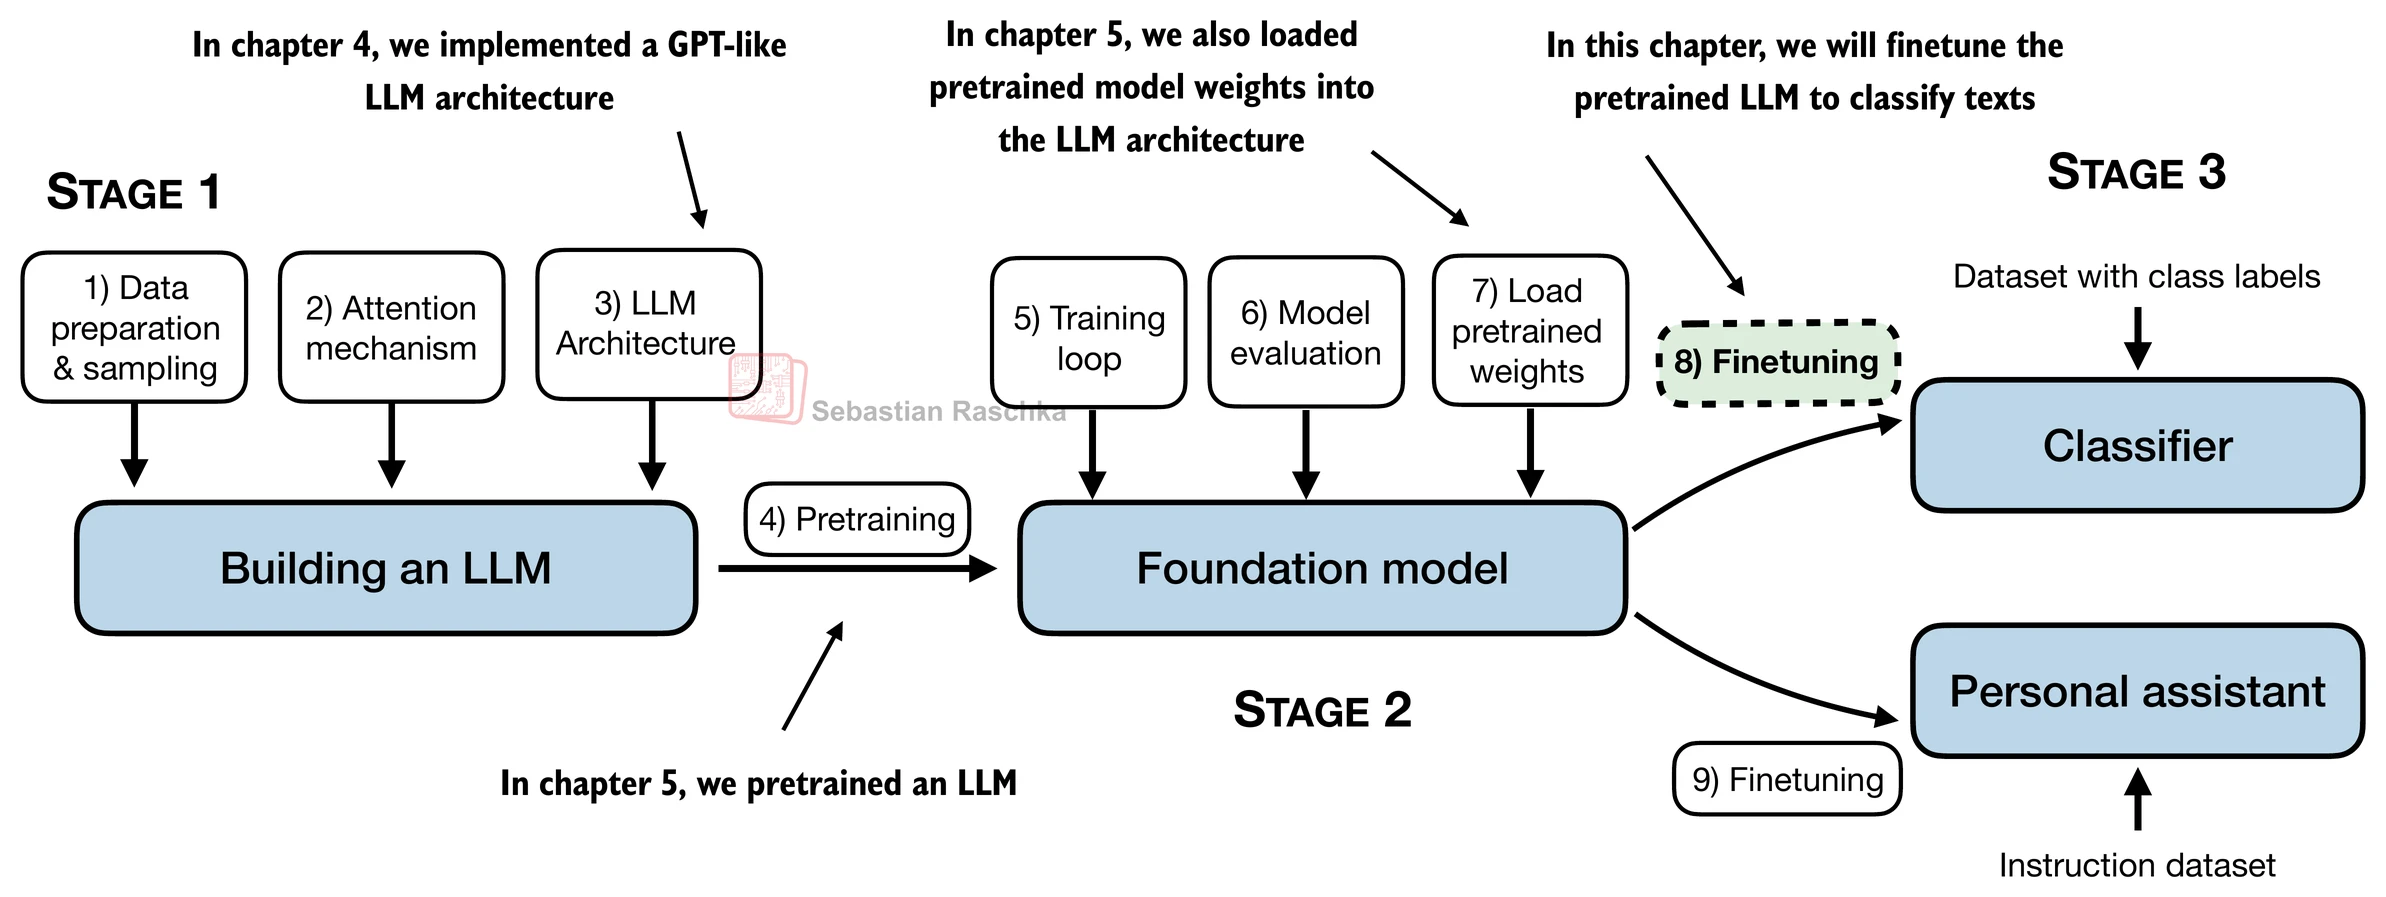

6.1 Different categories of finetuning
No code in this section
The most common ways to finetune language models are instruction-finetuning and classification finetuning
Instruction-finetuning, depicted below, is the topic of the next chapter

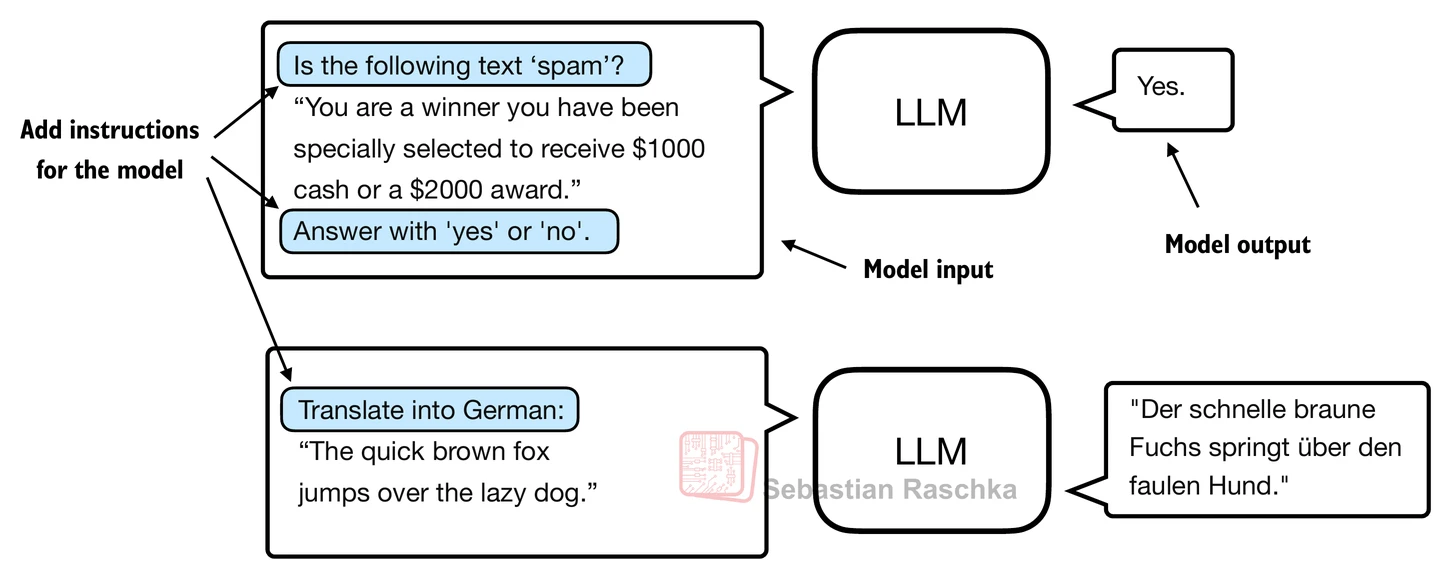

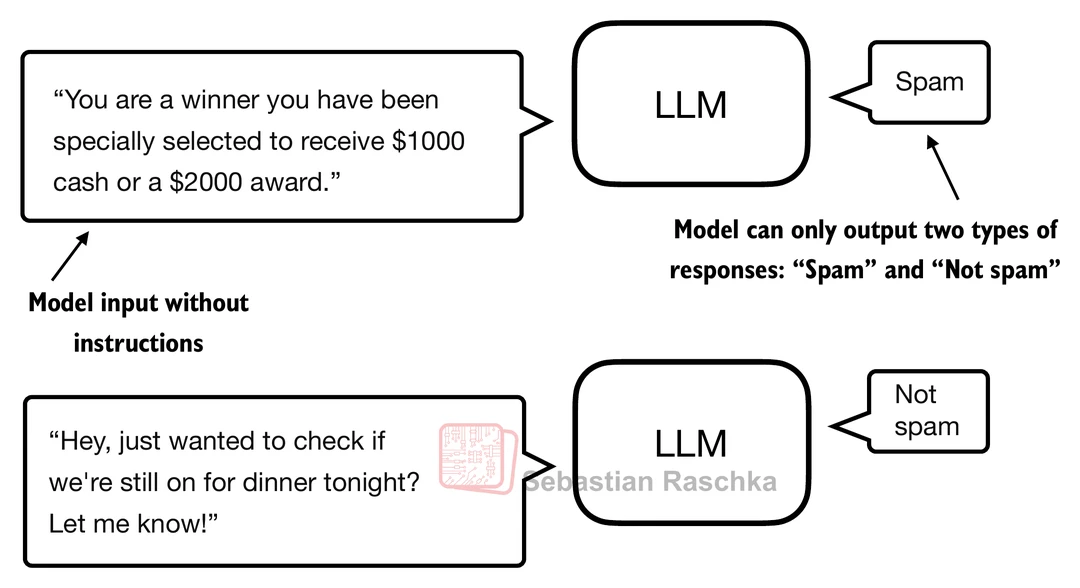

6.2 Preparing the dataset

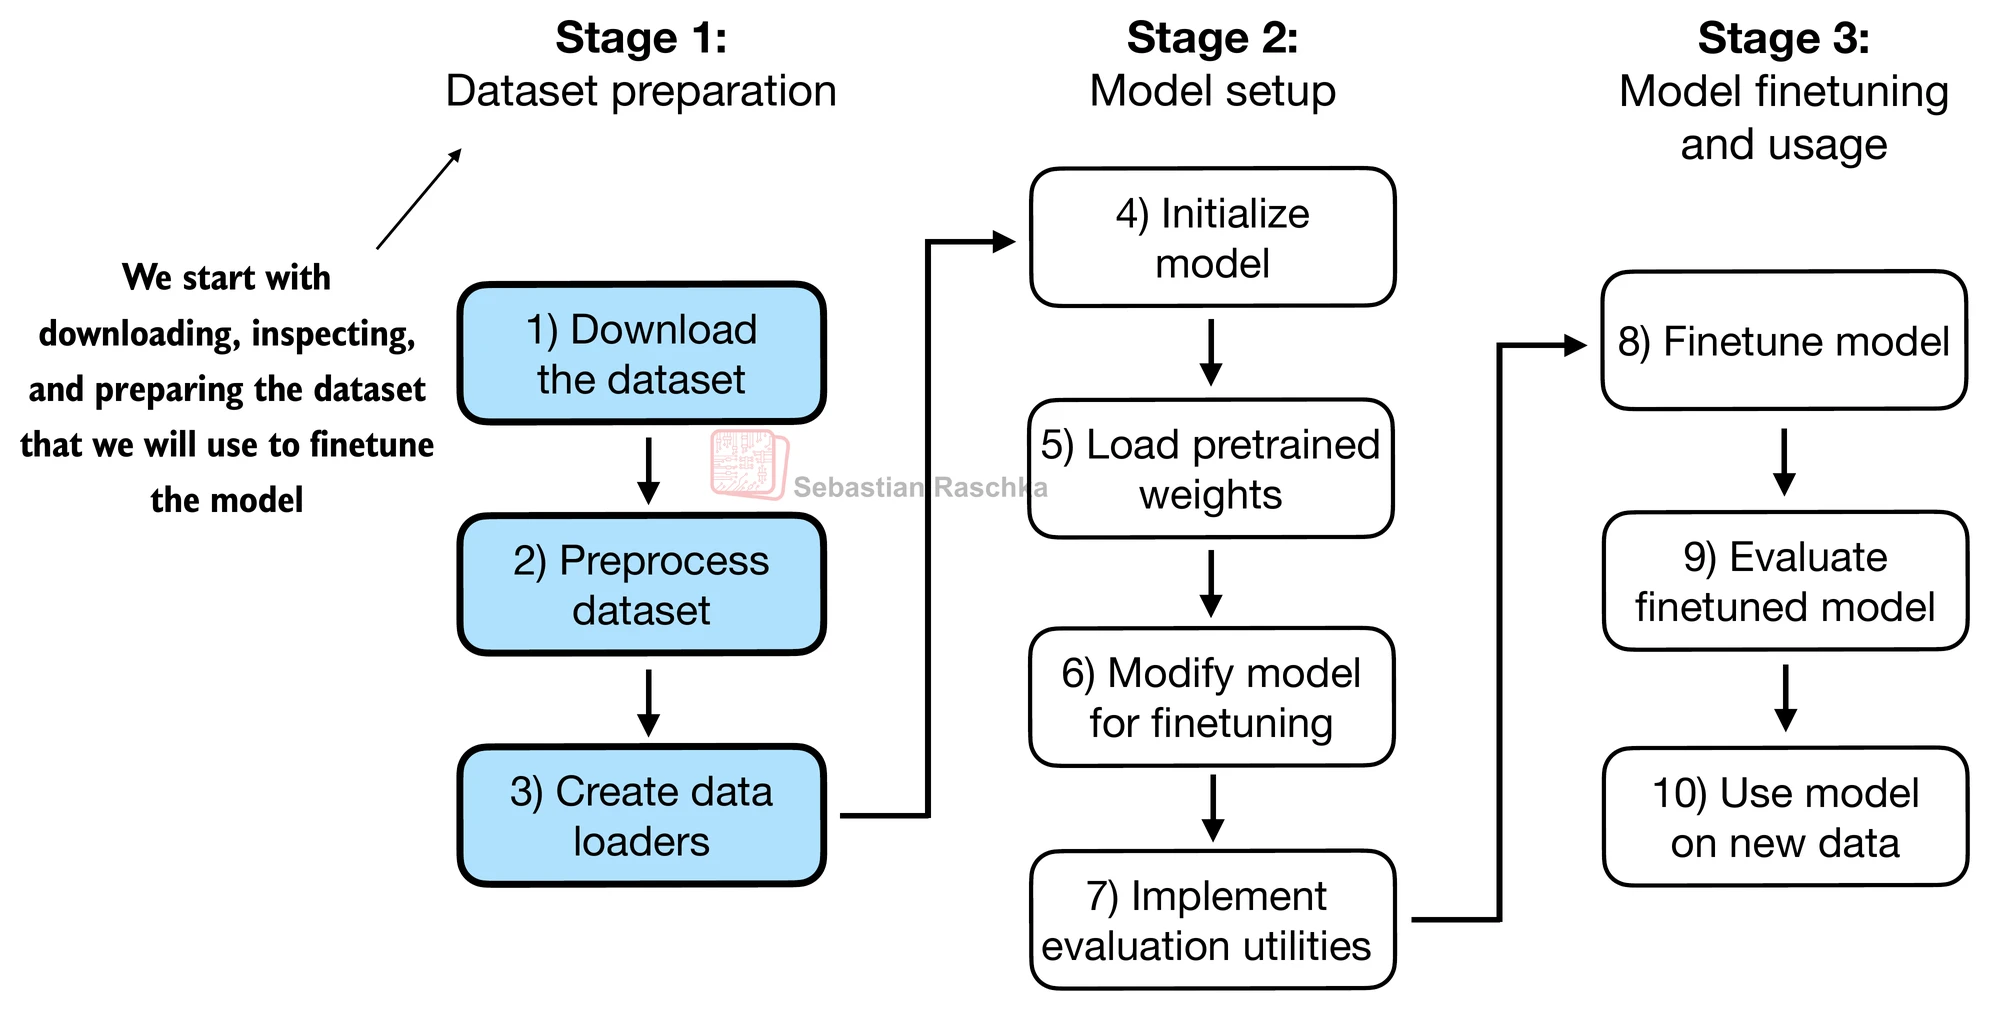

In [ ]:
# 从 UCI 机器学习仓库下载 SMS Spam Collection 数据集(短信垃圾/正常分类数据),并解压为 tsv 文件
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


# 定义下载+解压函数:若目标 tsv 文件已存在则直接跳过,避免重复下载
def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    # 中文:以流式方式发起 GET 请求,分块写入本地 zip 文件,timeout=60 秒防止请求卡死
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzipping the file
    # 中文:将下载好的 zip 包解压到 extracted_path 目录
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    # 中文:原始解压出的文件没有扩展名,这里重命名为 .tsv 便于后续用 pandas 读取
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


# 优先从官方 URL 下载;若下载失败(网络问题/超时)则自动回退到备用镜像地址重试
try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)



# The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.
# 中文说明:下面三引号包裹的代码块从未被执行,只是保留原书使用 urllib 实现的旧版下载逻辑作为参考

"""
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
"""

In [ ]:
# 读取 SMSSpamCollection.tsv(以制表符分隔),两列分别为 Label(ham/spam)和 Text(短信正文)
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

In [ ]:
# 统计并打印 Label 列中 ham(正常)与 spam(垃圾)各自的条数,用于查看类别是否平衡
print(df["Label"].value_counts())

In [ ]:
# 定义数据集平衡函数:对多数类(ham)做欠采样,使 ham 与 spam 数量相等,避免分类器偏向多数类
def create_balanced_dataset(df):
    # 统计 spam(少数类)样本数量
    num_spam=df[df["Label"]== "spam"].shape[0]
    # 从 ham 中随机抽取与 spam 数量相同的样本(固定 random_state 以便复现)
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    # 拼接欠采样后的 ham 子集与全部 spam 样本,得到类别平衡的数据集
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    return balanced_df
# 调用函数生成平衡数据集,并打印验证两类数量是否已一致
balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

In [ ]:
# 将文本标签映射为数值标签:ham(正常)->0,spam(垃圾)->1,便于后续计算分类交叉熵损失
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [ ]:
# 显示平衡后的数据集(Notebook 中直接输出 DataFrame 便于检查)
balanced_df

In [ ]:
# 将平衡数据集划分为训练/验证/测试集,并分别保存为 csv 文件,供后续 Dataset 类读取
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    # 中文:先打乱全部样本顺序(frac=1 表示按 100% 比例采样,即随机打乱),random_state 固定以便复现
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    # 中文:根据训练/验证比例计算切分下标
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    # 中文:按下标切片,得到训练/验证/测试三个子集
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

# 按 70% 训练 / 10% 验证 / (剩余)20% 测试的比例切分数据
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

# 将三个子集分别保存为 csv,后面的 SpamDataset 会从这些文件加载数据
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

6.3 Creating data loaders

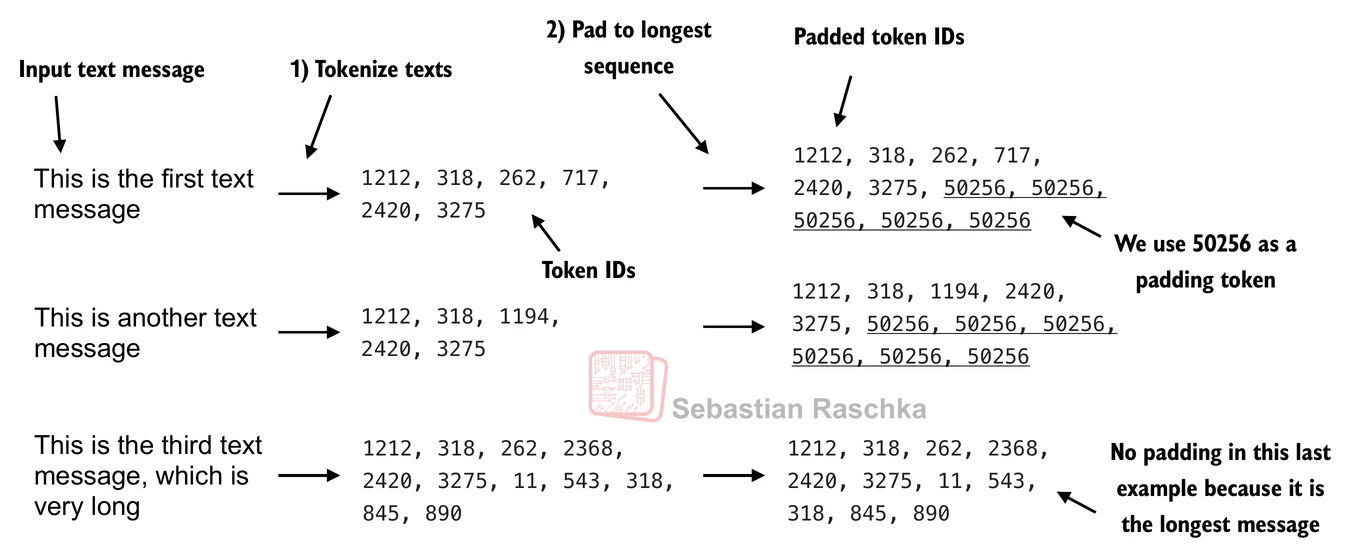

In [ ]:
# 使用 GPT-2 的 BPE 分词器(tiktoken),并确认 <|endoftext|> 特殊 token 的 id
# (应为 50256,后面会把它当作 padding token 使用)
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

In [ ]:
import torch
from torch.utils.data import Dataset


# 自定义 Dataset:预先把 csv 中的短信文本分词,并统一截断/填充为相同长度,标签转为 tensor
# 这样每个样本的输入张量形状固定为 (max_length,),才能被 DataLoader 拼成 batch
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        # 读取 csv(包含 Text 和 Label 两列)
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        # 中文:提前把所有文本编码为 token id 列表(此时各样本长度还不一致)
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        # 若未指定 max_length,则用数据集中最长编码序列的长度作为统一长度
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            # 中文:否则使用调用方传入的 max_length 作为统一长度
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            # 中文:对超过 max_length 的序列做截断,只保留前 max_length 个 token
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        # 中文:对不足 max_length 的序列,用 pad_token_id(默认 50256,即 <|endoftext|>)在末尾补齐
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    # 按索引取出一个样本:返回 (输入 token id 张量, 标签张量);
    # 输入张量形状为 (max_length,),标签为标量 0/1
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    # 数据集样本总数
    def __len__(self):
        return len(self.data)

    # 辅助方法:遍历所有编码文本,找出其中最长的 token 序列长度
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # Note: A more pythonic version to implement this method
        # is the following, which is also used in the next chapter:
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)
# 构建训练集:max_length=None 表示用训练集中最长样本的长度作为统一长度
# (验证集/测试集会复用这里得到的长度,保证输入维度一致)
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

# 打印训练集实际使用的序列长度(即训练集中最长样本的 token 数)
print(train_dataset.max_length)

In [ ]:
# 验证集/测试集必须使用与训练集相同的 max_length,以保证输入张量形状一致(模型输入维度固定)
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [ ]:
# 构建 DataLoader:batch_size=8。训练集打乱顺序(shuffle=True)并丢弃不满一个 batch 的尾部数据
# (drop_last=True),避免最后一个 batch 大小不一致导致梯度/统计量出现偏差
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

# 验证集/测试集不需要打乱顺序,也不丢弃最后不满一个 batch 的数据
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [ ]:
# 取一个训练 batch,查看输入和标签张量的形状:
# input_batch 形状为 (batch_size, max_length),target_batch 形状为 (batch_size,)
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)


In [ ]:
# 查看各个 DataLoader 的 batch 数量(样本数 // batch_size;训练集因 drop_last=True 会舍去余数)
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

6.4 Initializing a model with pretrained weights
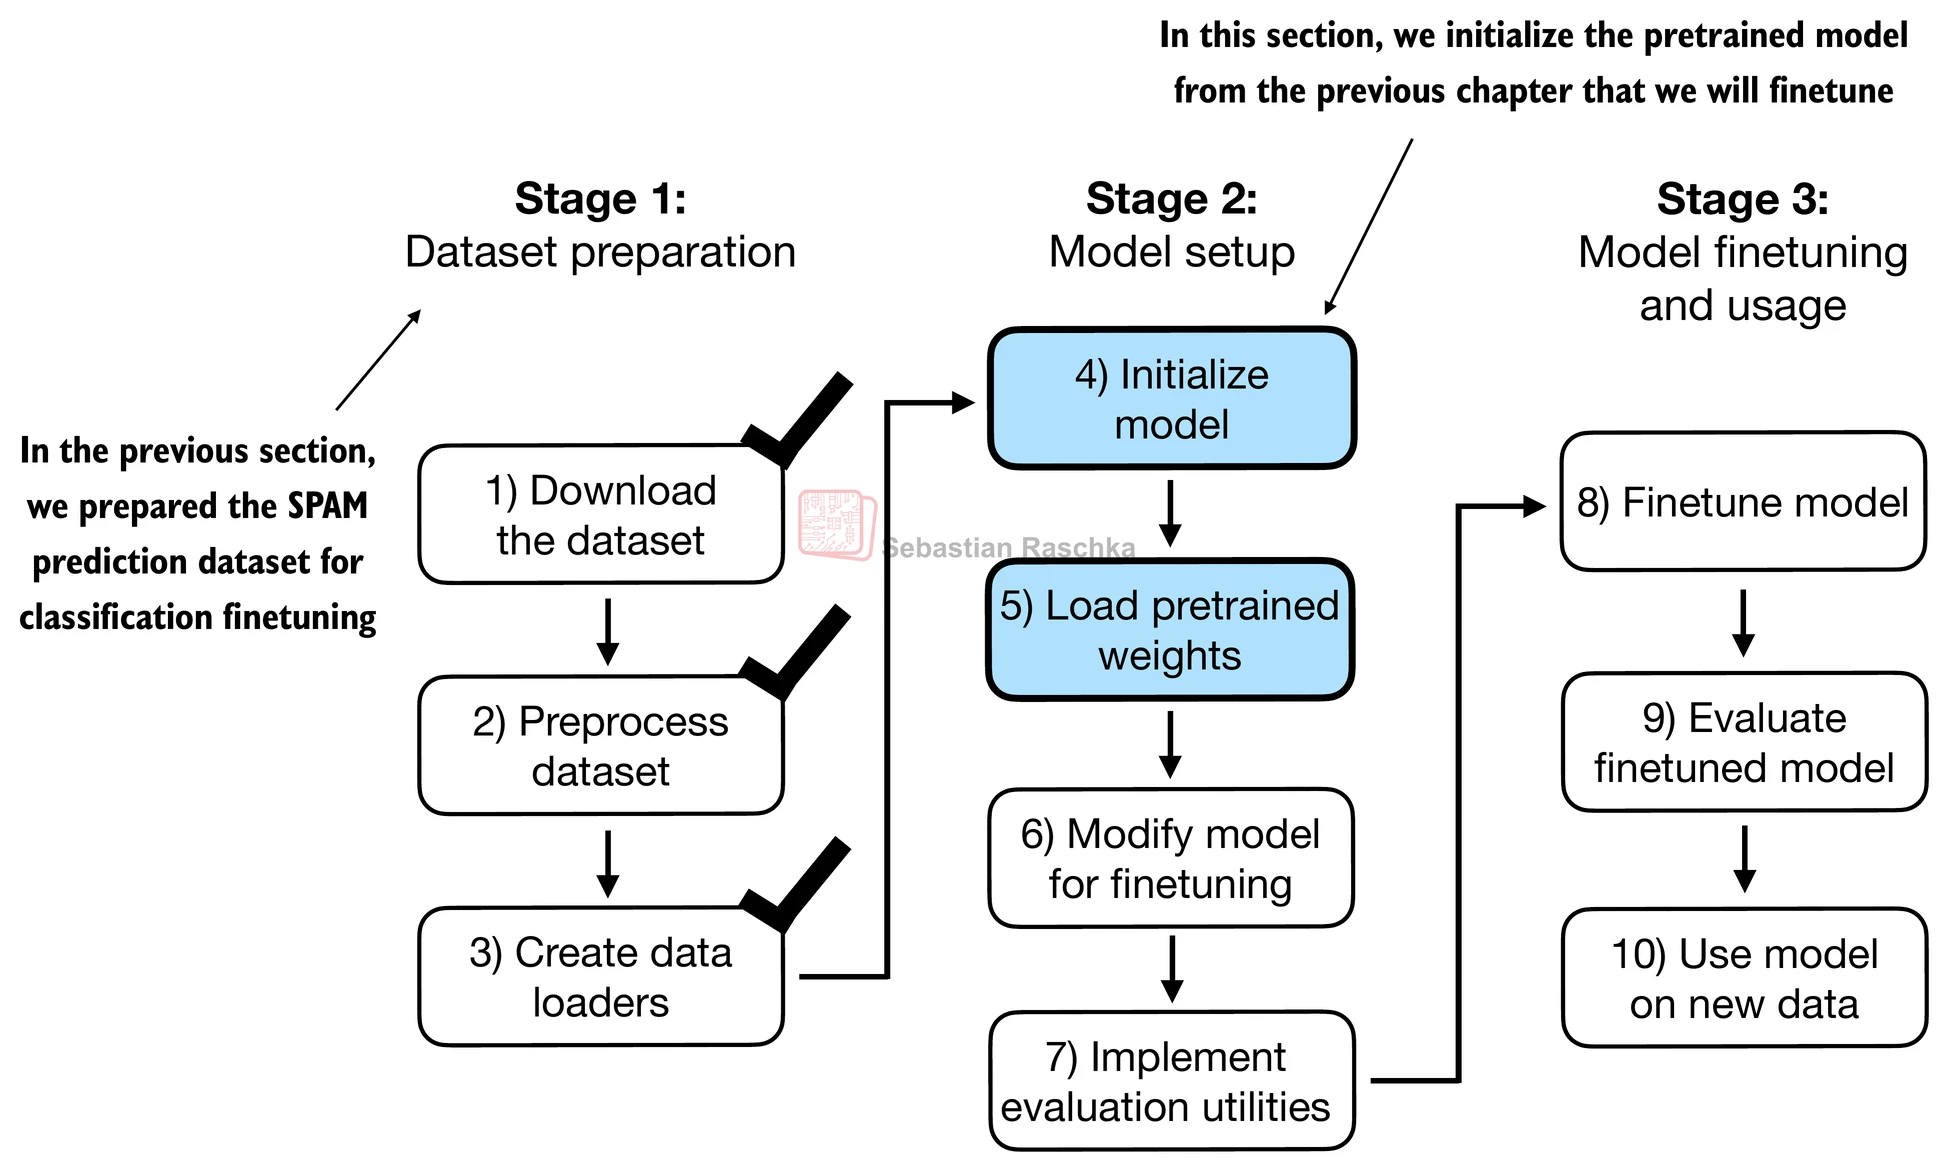

In [ ]:
# 选择要加载的 GPT-2 规模,并设置基础配置(词表大小、上下文长度、dropout、qkv 偏置)
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

# 不同规模 GPT-2 的结构差异:embedding 维度、Transformer 层数、注意力头数
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

# 确保数据集样本长度不超过模型支持的上下文长度,否则需用更大的 context_length 重新构建数据集
assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [ ]:
# 下载并加载 OpenAI 发布的 GPT-2 预训练权重
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel
# from llms_from_scratch.ch05 import download_and_load_gpt2, load_weights_into_gpt

# 从 CHOOSE_MODEL 字符串中提取参数规模标识,例如 '124M'
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

# 用配置初始化模型结构,再把下载好的预训练权重载入其中
# (此时模型仍是原始语言模型,输出层 out_head 是词表大小的 logits)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

In [ ]:
# 用尚未微调的原始 GPT-2(语言模型头)做文本续写,验证预训练权重是否加载正确
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

# Alternatively:
# from llms_from_scratch.ch05 import (
#    generate_text_simple,
#    text_to_token_ids,
#    token_ids_to_text
# )


# 简单的续写测试
text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

In [ ]:
# 尝试用提示词(prompt)方式让基础语言模型判断短信是否为垃圾邮件——通常效果不佳,
# 这正是本章要通过替换分类头并微调来解决的问题
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

6.5 Adding a classification head
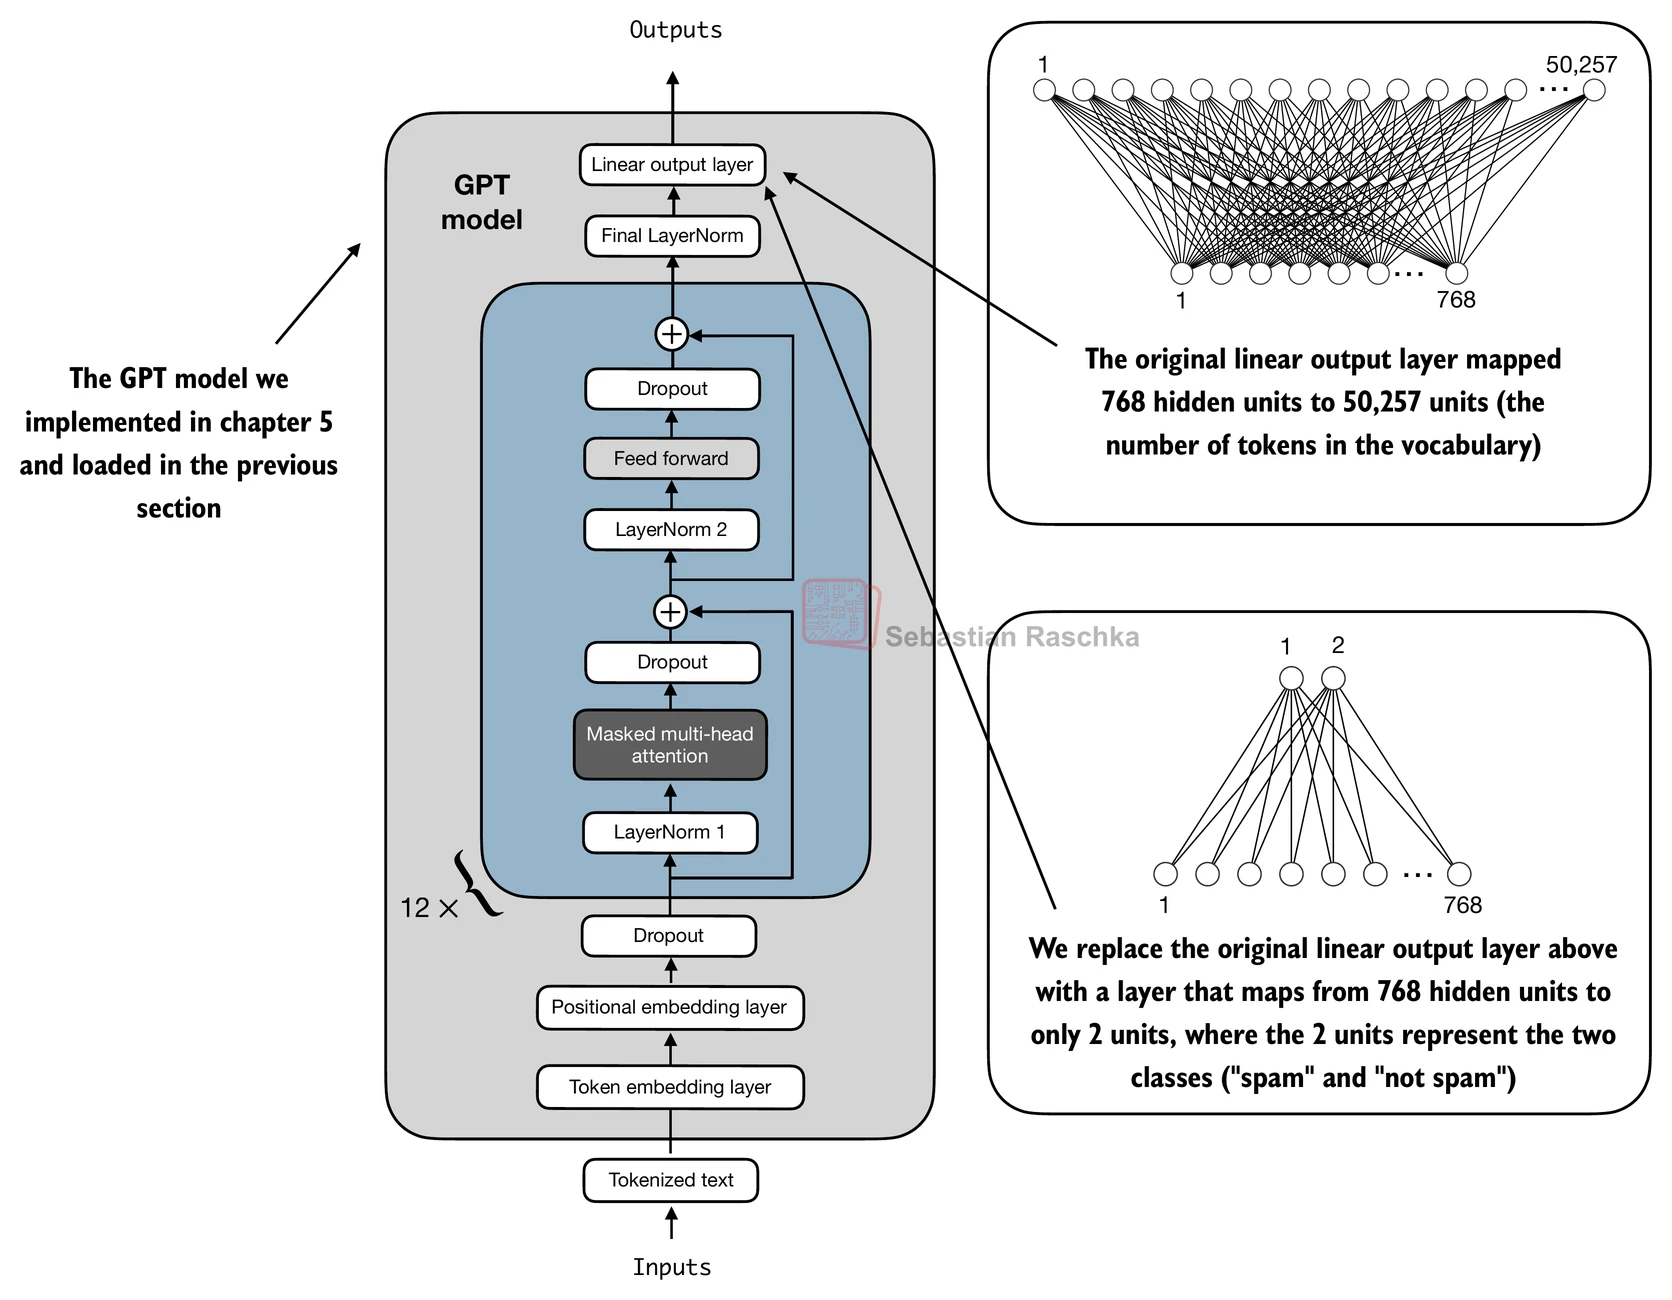

In [ ]:
# 打印模型结构,确认当前最后一层 out_head 是输出 vocab_size 维 logits 的线性层
print(model)

In [ ]:
# 冻结模型全部参数(requires_grad=False),即先禁止预训练权重被梯度更新,
# 后面只会有选择地解冻少数层,实现“部分微调”而不是从头训练整个模型
for param in model.parameters():
    param.requires_grad = False

In [ ]:
# 固定随机种子,保证新分类头权重初始化可复现
torch.manual_seed(123)

# 二分类任务:0 = ham(正常短信),1 = spam(垃圾短信)
num_classes = 2
# 用一个新的线性层替换原来的语言模型输出头
# (原来 out_head 输出维度是 vocab_size=50257,现在改为 num_classes=2)
# 新建的 nn.Linear 默认 requires_grad=True,因此目前只有这个分类头是可训练的
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

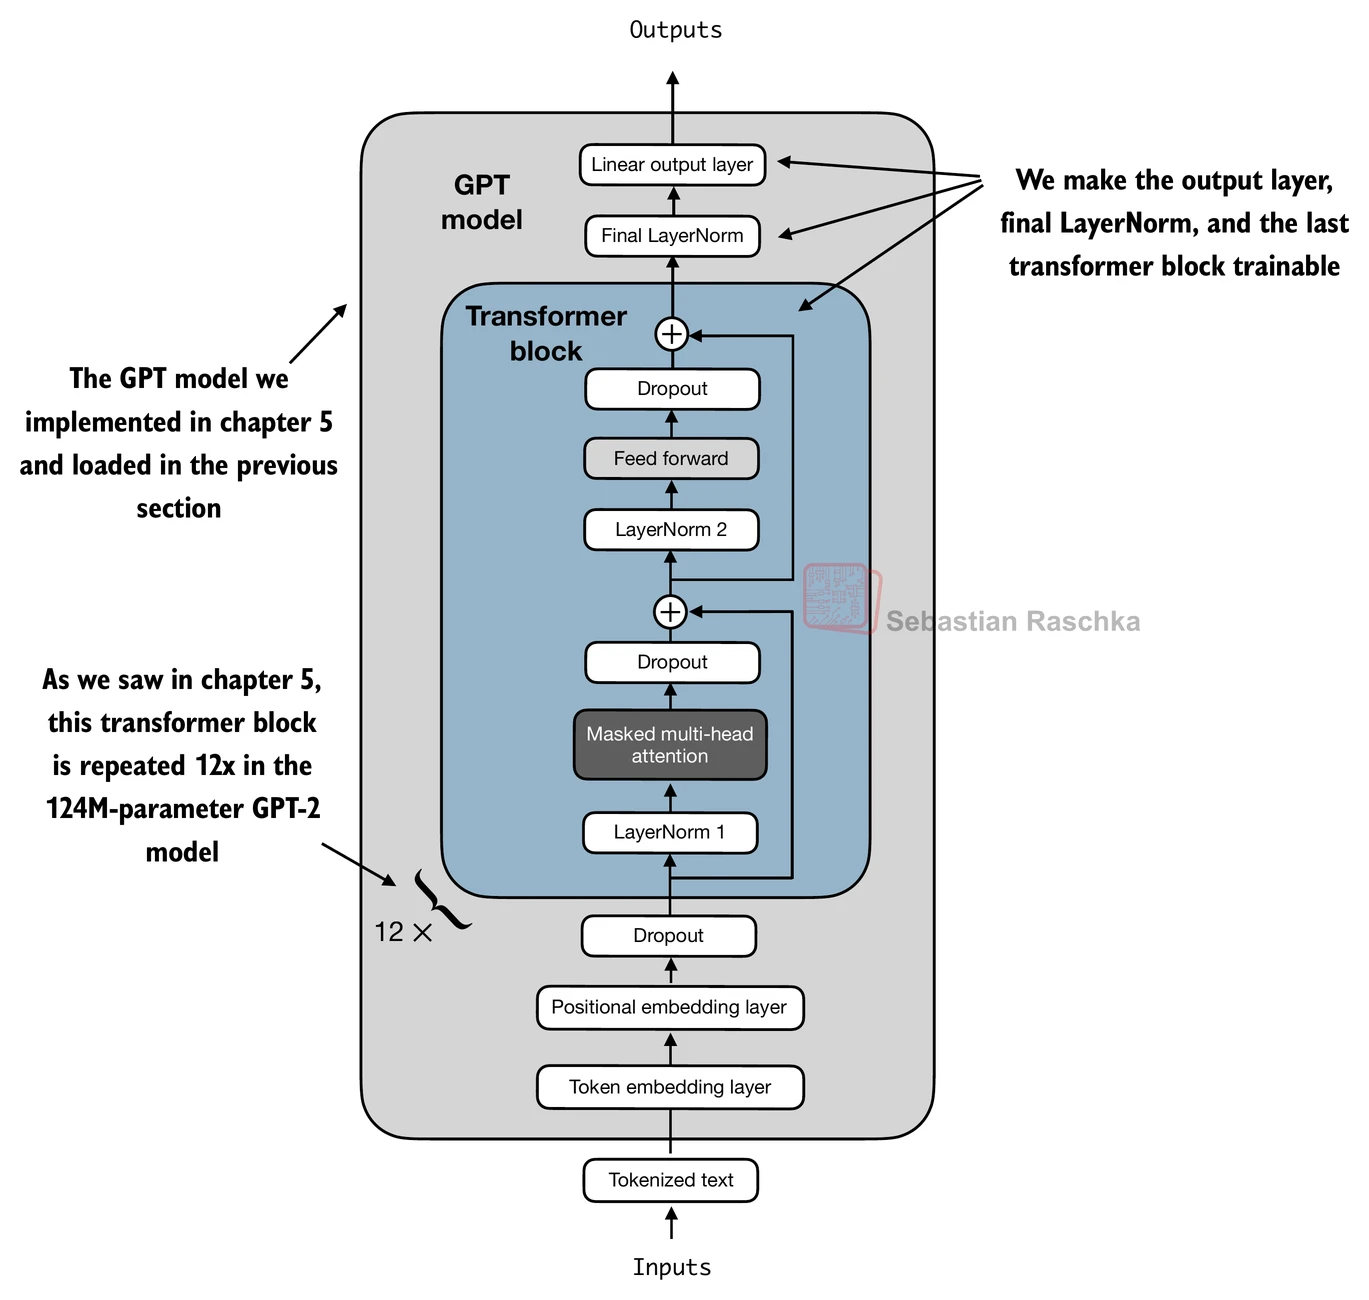

In [ ]:
# 除了新的分类头外,额外解冻最后一个 Transformer block 的参数,
# 让模型在微调时有更多可调整的容量,通常比“只训练分类头”效果更好
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

# 同时解冻最终归一化层(final_norm)的参数,使其也参与微调
for param in model.final_norm.parameters():
    param.requires_grad = True

In [ ]:
# 用一句简单文本测试当前模型(已替换分类头,尚未微调)的前向输出
inputs = tokenizer.encode("Do you have time")
# unsqueeze(0) 增加 batch 维度,得到形状 (batch_size=1, num_tokens)
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

In [ ]:
# 前向传播(不计算梯度,仅做推理观察输出形状)
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

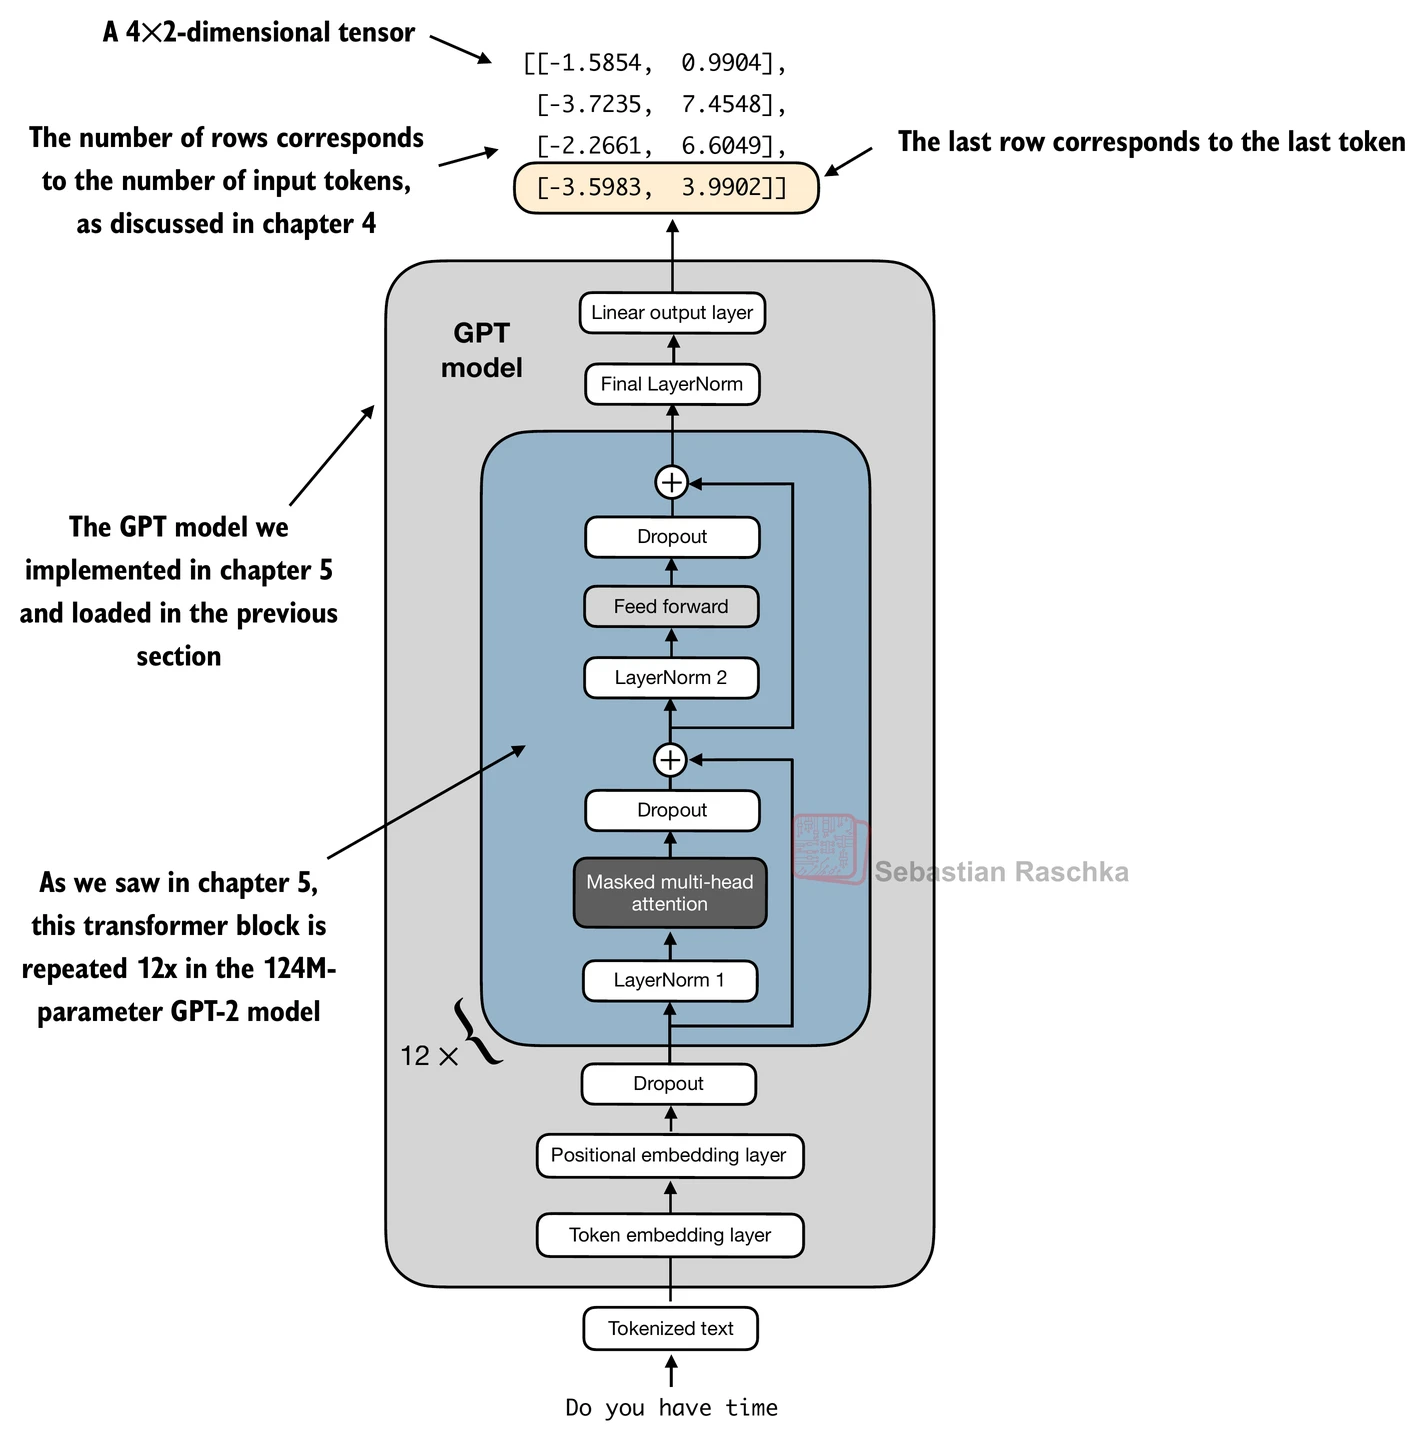

In [ ]:
# 只取序列最后一个位置的输出:因果自注意力下,最后一个 token 能看到前面所有 token,
# 类似 GPT 训练时用于预测下一个 token 的位置,这里复用该位置的向量做分类
print("Last output token:", outputs[:, -1, :])

6.6 Calculating the classification loss and accuracy
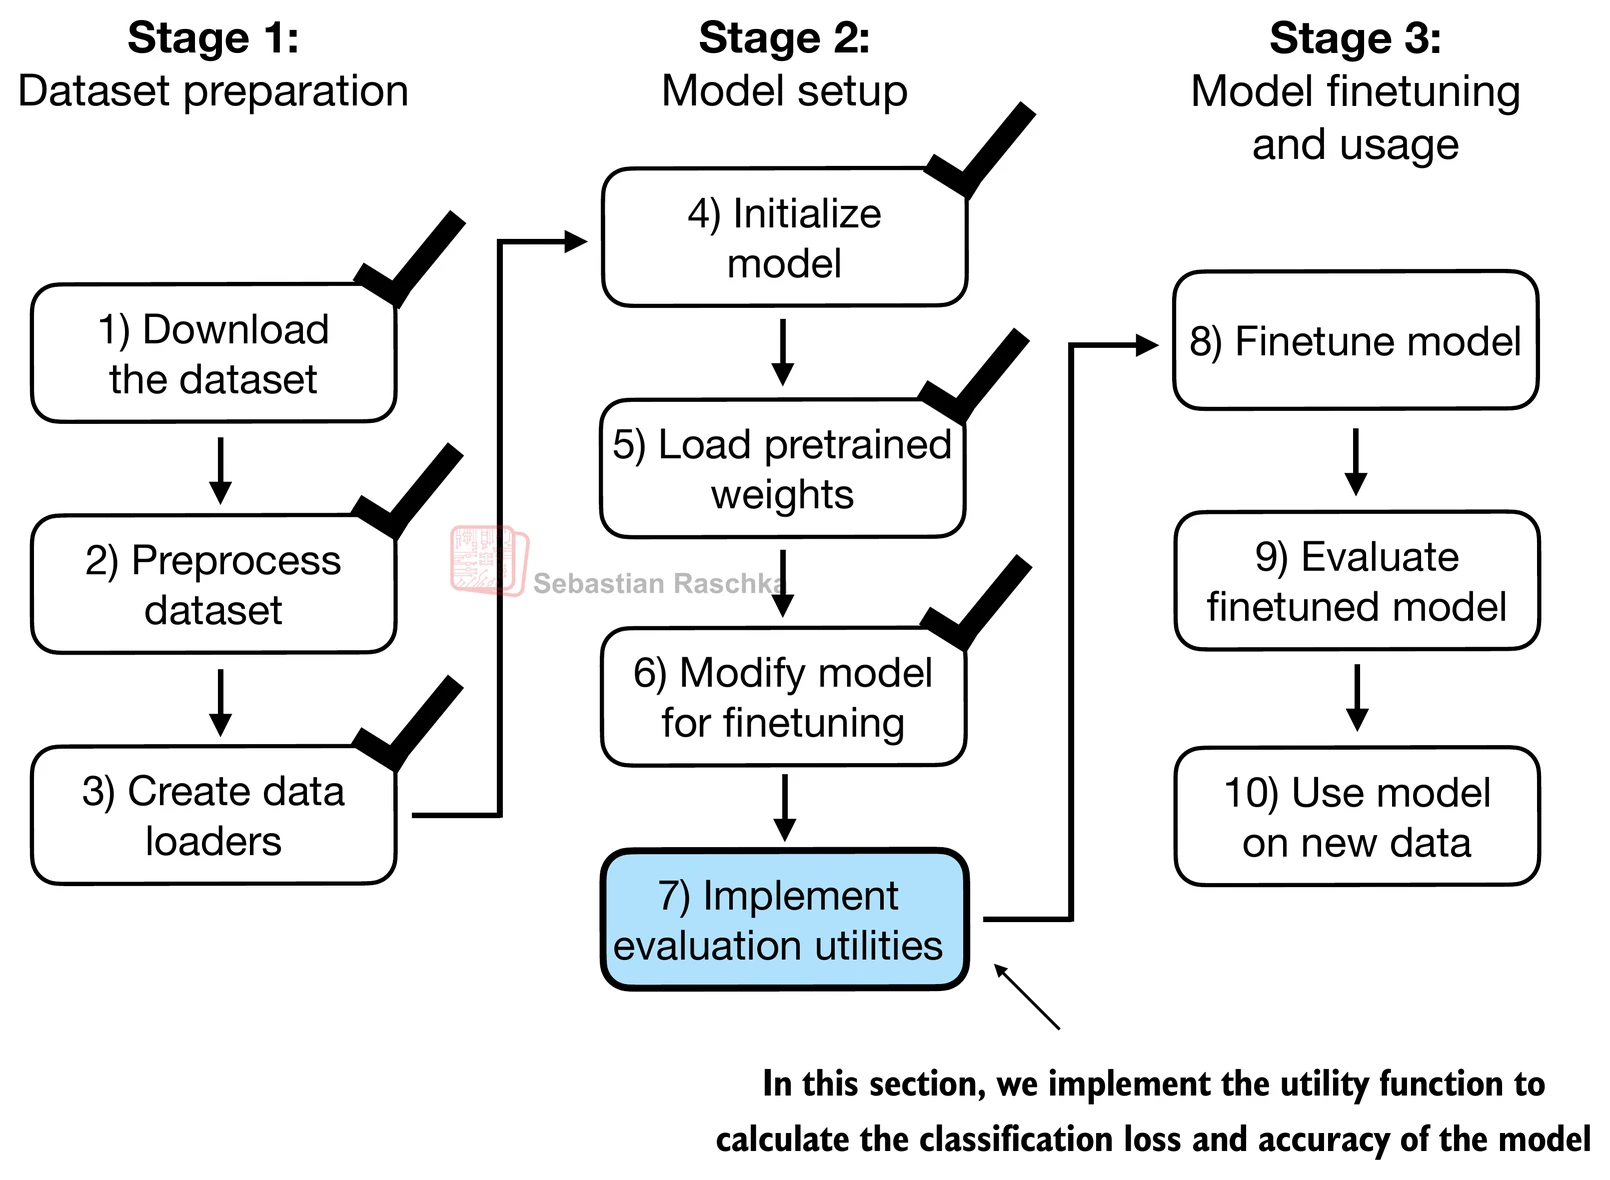
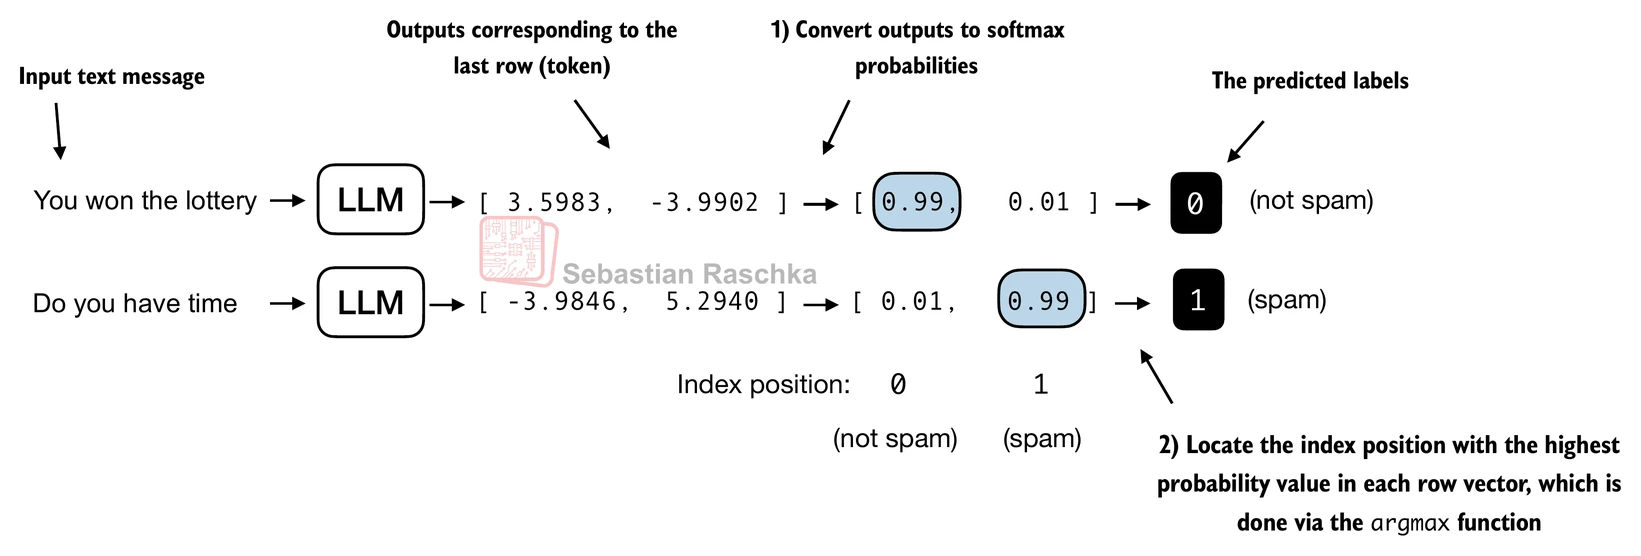

In [ ]:
# 再次查看最后一个 token 的输出向量(此时维度是 2,对应 ham/spam 两个类别的 logits)
print("Last output token:", outputs[:, -1, :])

In [ ]:
# 对 logits 做 softmax 得到概率分布,再取概率最大的类别作为预测标签
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

In [ ]:
# softmax 是单调变换,不改变最大值所在的位置,因此直接对 logits 取 argmax 结果相同,
# 推理/评估时可以省去 softmax 这一步以节省计算
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

In [ ]:
# 计算分类准确率:遍历 data_loader 中的 batch,统计预测正确的样本数占比
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    # 切换到 eval 模式(关闭 dropout 等只在训练时生效的行为)
    model.eval()
    correct_predictions, num_examples = 0, 0

    # num_batches 用于只抽查部分 batch(例如训练早期粗略估计准确率);不传则遍历全部 batch
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    # 逐 batch 计算
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            # 推理阶段不需要梯度,节省显存和计算
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            # 取每个样本预测概率最大的类别作为预测标签
            predicted_labels = torch.argmax(logits, dim=-1)

            # 累加已处理样本数,以及预测正确的样本数
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    # 正确率 = 预测正确的样本数 / 总样本数
    return correct_predictions / num_examples

In [ ]:
# 选择运算设备:优先 cuda,其次 mps(Apple Silicon,需 PyTorch>=2.9 才稳定),否则回退 cpu
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

# 微调前先用少量 batch(num_batches=10)粗略评估基线准确率,作为微调效果的参照
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

In [ ]:
# 单个 batch 的分类损失:同样只取最后一个 token 位置的 logits,与真实标签做交叉熵
# 注意这里的 target 是类别索引(0/1),不同于语言模型里“下一个 token id”的目标
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [ ]:
# Same as in chapter 5
# 中文:对多个 batch 的损失取平均,得到整个(或部分)数据集上的平均损失
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [ ]:
# 微调前用少量 batch 计算基线损失,便于和微调后的损失做对比
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

6.7 Finetuning the model on supervised data
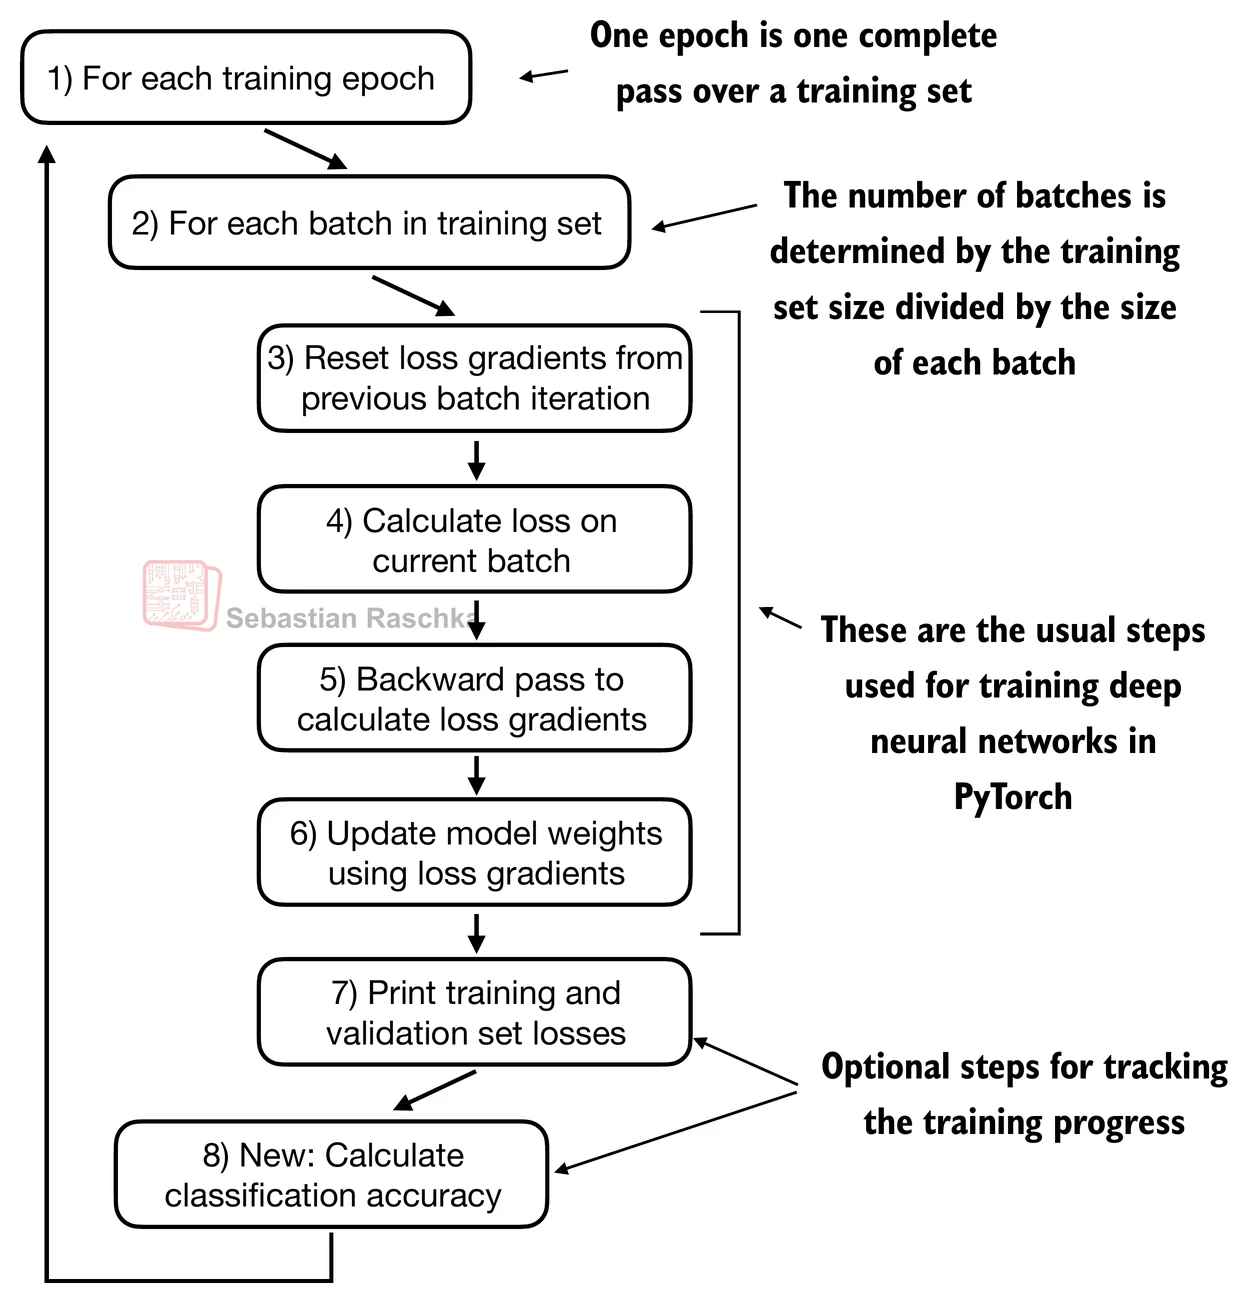

In [ ]:
# Overall the same as `train_model_simple` in chapter 5
# 中文:分类任务的训练主循环。与第 5 章语言模型训练的主要区别是:
# 这里按“已处理样本数”(examples_seen)而不是“已处理 token 数”统计训练进度,
# 并且每个 epoch 结束后会额外计算一次训练/验证准确率
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        # 遍历训练集的每个 batch
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            # 中文:每隔 eval_freq 步在训练集/验证集上评估一次损失,用于监控训练是否收敛
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        # 中文:每个 epoch 结束后,用 eval_iter 个 batch 估算训练/验证准确率
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [ ]:
# Same as chapter 5
# 中文:临时切到 eval 模式计算训练/验证损失(不更新参数),算完再切回 train 模式,
# 避免影响 dropout 等训练专用状态
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [ ]:
# 开始正式微调:使用 AdamW 优化器,学习率 5e-5,权重衰减 0.1,训练 5 个 epoch
# 由于大部分参数已冻结,实际只有分类头 + 最后一个 Transformer block + final_norm 会被更新
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

In [ ]:
# 绘制训练/验证曲线的辅助函数:同时展示“按 epoch”和“按已处理样本数”两种 x 轴刻度
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

In [ ]:
# 构造与损失记录点对应的 x 轴坐标(等间隔的 epoch 数与样本数),绘制训练/验证损失曲线
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

In [ ]:
# 同样地绘制训练/验证准确率曲线
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [ ]:
# 微调完成后,在完整的训练/验证/测试集上(不再限制 num_batches)计算最终准确率
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

6.8 Using the LLM as a spam classifier
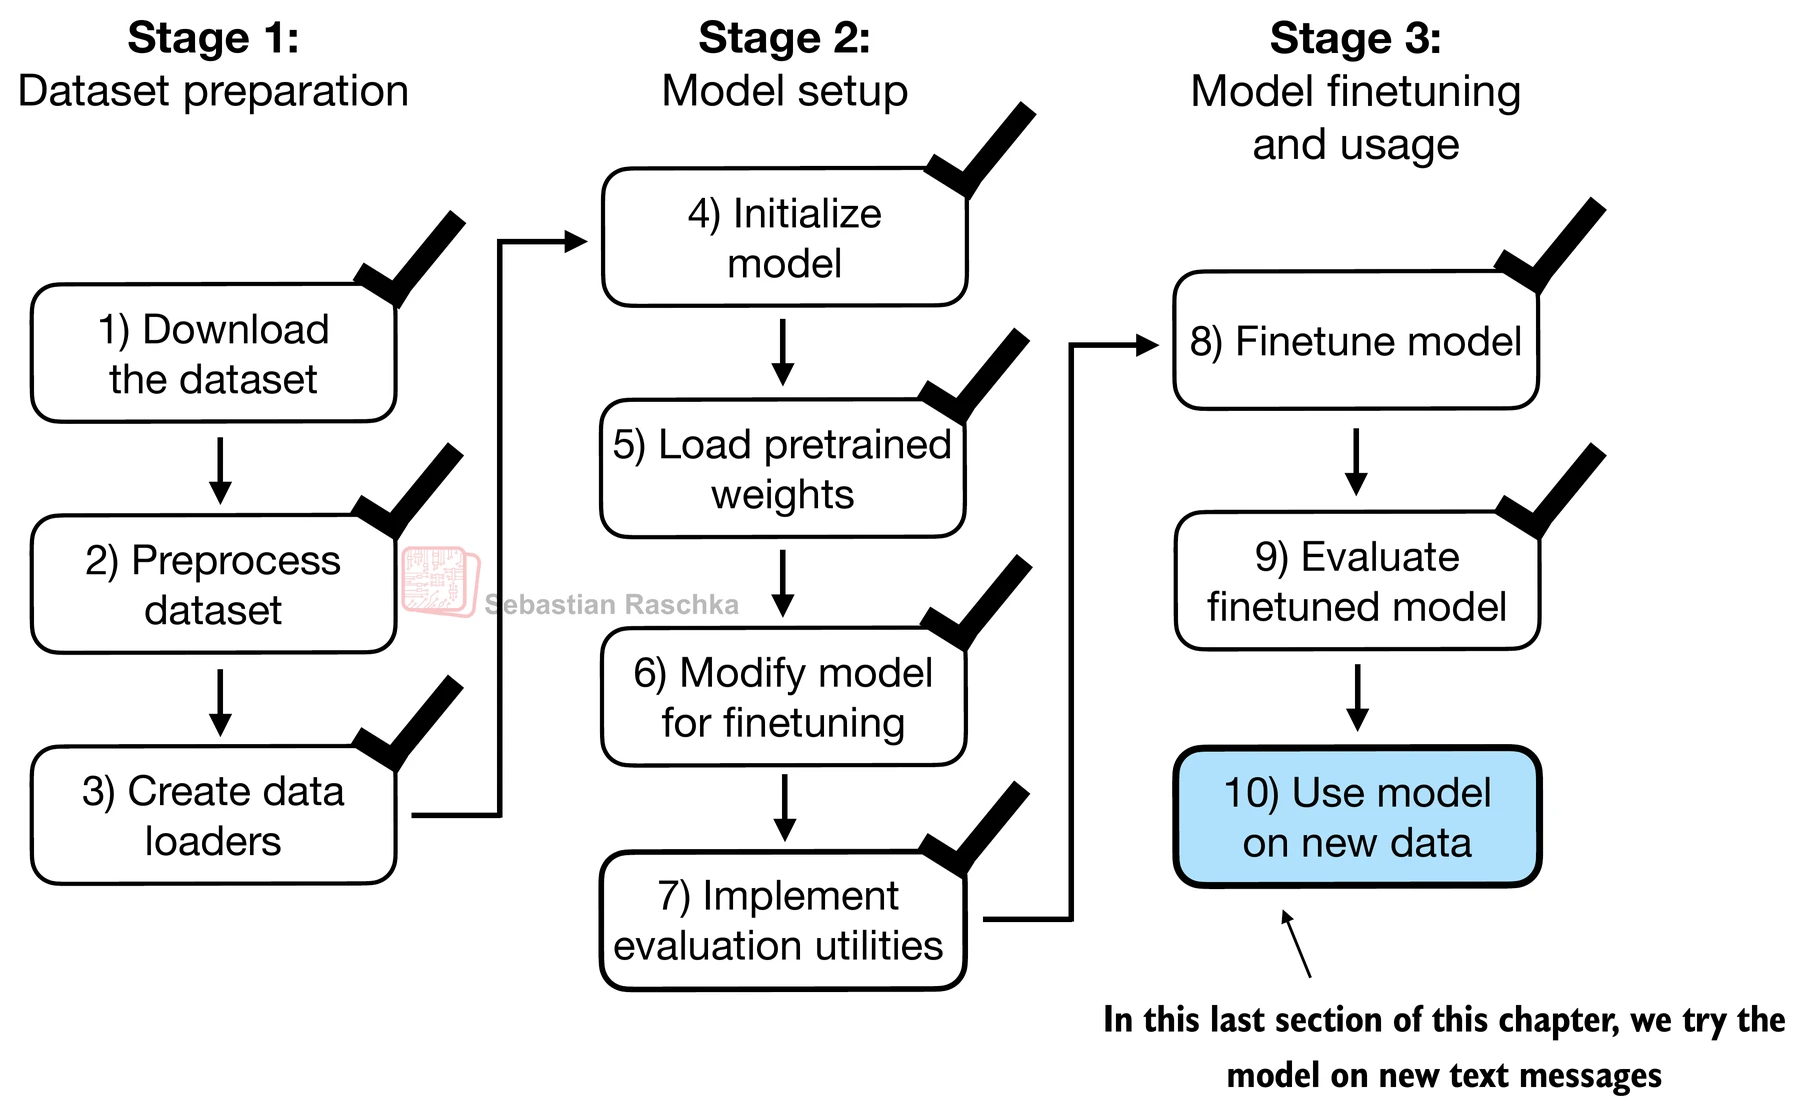

In [ ]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    # 对输入文本分词
    input_ids = tokenizer.encode(text)
    # 模型支持的最大上下文长度,取自位置编码矩阵的行数(即 context_length)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # [中文 bug 修复标注] 原代码先执行 `input_ids[:min(max_length, supported_context_length)]`,
    # 再执行下面的 assert 检查;但若调用方传入 max_length=None,`min(None, int)` 会先抛出
    # TypeError,导致下面这条本该给出的友好报错信息永远无法触发。这里把两个 assert 检查
    # 提前到截断逻辑之前,使其真正起到保护作用(对本 notebook 中实际的调用方式无影响,
    # 因为这里 max_length 始终以 int 形式传入)。
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]
    # Alternatively, a more robust version is the following one, which handles the max_length=None case better
    # max_len = min(max_length,supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]

    # Pad sequences to the longest sequence
    # 用 pad_token_id 补齐到 max_length,与训练时 SpamDataset 的数据处理方式保持一致
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    # 前向推理,只取最后一个 token 位置的 2 维 logits(分别对应 ham/spam 两个类别)
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    # 类别 1 对应 spam,0 对应 ham(not spam)
    return "spam" if predicted_label == 1 else "not spam"

In [ ]:
# 用一条明显的垃圾短信样例测试微调后的分类效果
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

In [ ]:
# 再用一条正常短信样例测试,确认模型不会把普通对话误判为垃圾短信
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

In [ ]:
# 保存微调后模型的参数(state_dict),之后可直接加载使用,无需重新训练
torch.save(model.state_dict(), "review_classifier.pth")

In [ ]:
# 演示如何从磁盘恢复模型:先加载 state_dict(weights_only=True 更安全),再用 load_state_dict 加载到模型结构中
# 注意:这里的 model 必须已经是替换过分类头(out_head 输出维度=2)之后的结构,否则权重形状对不上
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)